Mean Absolute Error: 174662.93438524107
R2 Score: 0.5089347172264876


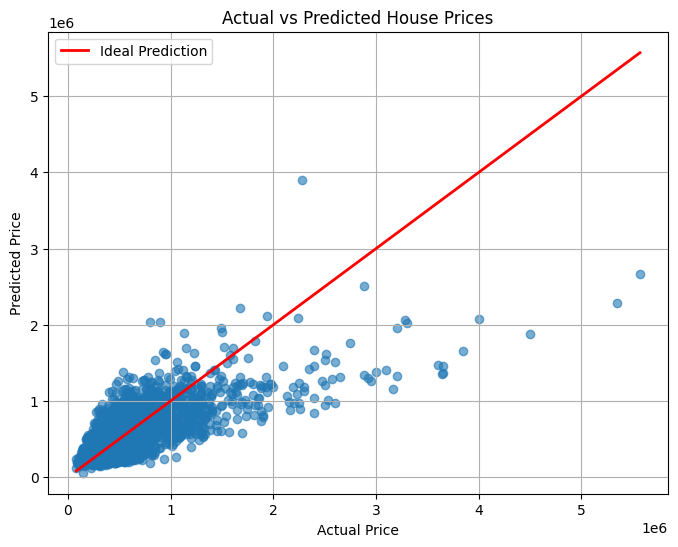

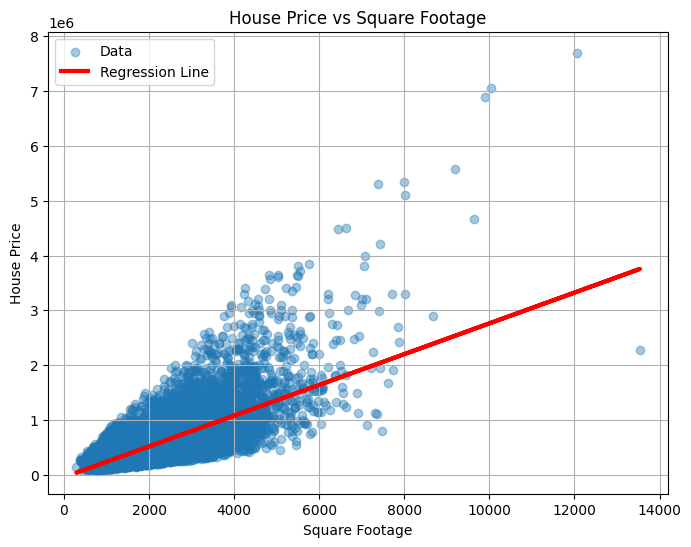


Sample Predictions:
   Actual Price  Predicted Price
0      365000.0     5.024956e+05
1      865000.0     7.082811e+05
2     1038000.0     1.024918e+06
3     1490000.0     1.334049e+06
4      711000.0     7.084036e+05
5      211000.0     3.896388e+05
6      790000.0     6.948205e+05
7      680000.0     4.791690e+05
8      384500.0     4.180397e+05
9      605000.0     2.465721e+05


In [ ]:
# House Price Prediction using Linear Regression
# SkillCraft Technology - Task 01

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load Dataset
df = pd.read_csv("/content/kc_house_data.csv")

# Select Features and Target
X = df[['sqft_living', 'bedrooms', 'bathrooms']]
y = df['price']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict Prices
y_pred = model.predict(X_test)

# Evaluate Model
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------------------
# Graph 1: Actual vs Predicted
# -----------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Ideal Prediction'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------------
# Graph 2: Regression Line
# -----------------------------------------
single_model = LinearRegression()
single_model.fit(df[['sqft_living']], df['price'])

plt.figure(figsize=(8,6))
plt.scatter(df['sqft_living'], df['price'], alpha=0.4, label='Data')

plt.plot(
    df['sqft_living'],
    single_model.predict(df[['sqft_living']]),
    color='red',
    linewidth=3,
    label='Regression Line'
)

plt.xlabel("Square Footage")
plt.ylabel("House Price")
plt.title("House Price vs Square Footage")
plt.legend()
plt.grid(True)
plt.show()

# Display Sample Predictions
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nSample Predictions:")
print(results.head(10))